In [1]:
from pathlib import Path
import random

from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import functional as TF
import matplotlib.pyplot as plt
import einx
import math
import time
from pathlib import Path
from dataclasses import dataclass

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.cuda.amp import autocast, GradScaler
from torchvision.utils import make_grid
from IPython.display import display

import random
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision.transforms import Resize
import einx

from pathlib import Path
import gc
import torch
import einx

import glob



try:
    import lpips
except ImportError:
    lpips = None
    print("lpips is not installed. Run: pip install lpips")

## Training Dataset Preprocessing

We expect to have gone through the image_dataset_preprocessing.ipynb at this point and have a processedDatasets/FOLDERNAME where inside we have a bunch of arbitrarily named webps of a standardized size.

We also expect to have trained an autoencoder by this point. We will generate a new dataset of only the latent representations of each of our images from our webp dataset using the Encoder. I am generally saving this dataset also to the processedDatasets folder and prefixing the subfolder name with "Latent" 

**Important!** There are a lot of paths and walrus operators you may want to change here from the source image dataset path, target latent dataset path, and a walrus operator somewhere on whether or not you want to re-process everything.

In [2]:
DATASET_NAME = "Fantasy-512x384"

PROCESSED_ROOT = Path("processedDatasets") / DATASET_NAME

IMAGE_EXTENSIONS = {".webp",}


In [4]:
def to_neg1_1(x: torch.Tensor) -> torch.Tensor:
    return x * 2.0 - 1.0
    
class ProcessedImageDataset(Dataset):
    """
    Dataset for flattened processed image folders.

    __getitem__ returns:

        original:
            torch.float32 tensor in [0, 1]
            shape: (3, H, W)

        lpips_ready:
            torch.float32 tensor in [-1, 1]
            shape: (3, H, W)
            has 50% chance of horizontal flip
    """

    def __init__(
        self,
        root: str | Path,
        image_extensions: set[str] = IMAGE_EXTENSIONS,
        horizontal_flip_prob: float = 0.5,
    ):
        self.root = Path(root)
        self.image_extensions = {ext.lower() for ext in image_extensions}
        self.horizontal_flip_prob = horizontal_flip_prob

        if not self.root.exists():
            raise FileNotFoundError(f"Dataset folder does not exist: {self.root}")

        self.image_paths = sorted(
            p for p in self.root.iterdir()
            if p.is_file() and p.suffix.lower() in self.image_extensions
        )

        if len(self.image_paths) == 0:
            raise ValueError(f"No images found in: {self.root}")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index: int):
        path = self.image_paths[index]

        with Image.open(path) as img:
            img = img.convert("RGB")

            # Converts PIL image to float32 torch tensor in [0, 1],
            # with shape (C, H, W).
            original = TF.to_tensor(img).float()

        augmented = original.clone()

        if random.random() < self.horizontal_flip_prob:
            augmented = TF.hflip(augmented)

        lpips_ready = to_neg1_1(augmented)

        return original, lpips_ready
dataset = ProcessedImageDataset(PROCESSED_ROOT)

print(len(dataset), dataset[0][0].shape, dataset[0][1].shape)
plt.imshow(einx.id("c h w -> h w c",dataset[0][0]))

## Big Ass Config Dataclass With Decent Defaults

I copied this from the last notebook by hand and should consolidate it into a .py file since some of the stuff is not useful in this notebook and it's reused.

In [8]:
@dataclass
class VQGANConfig:
    image_height: int = 512
    image_width: int = 384
    image_channels: int = 3

    # Compression factor.
    f: int = 8

    # Codebook embedding dimension.
    z_channels: int = 3

    # Number of discrete codebook entries.
    n_embed: int = 1024 * 8

    # VQGAN commitment weight, beta in the paper-style codebook loss.
    beta: float = 0.25

    # Base Channels For Encoder And Decoder
    base_channels: int = 64

    # Loss weights.
    perceptual_weight: float = 1.0
    reconstruction_weight: float = 1.0
    codebook_weight: float = 1.0

    # Adversarial settings.
    disc_start_step: int = 3000
    disc_weight: float = 0.3
    disc_factor: float = 1.0
    adaptive_weight_max: float = 300

    # Optimizer.
    lr: float = 4.5e-6
    betas: tuple = (0.5, 0.9)

    # Training.
    epochs: int = 100
    batch_size: int = 8
    num_workers: int = 2
    grad_accum_steps: int = 1

    # Logging/checkpointing.
    sample_every_steps: int = 500
    out_dir: str = "runs/vqgan_fantasy"


cfg = VQGANConfig()

assert cfg.image_height % cfg.f == 0
assert cfg.image_width % cfg.f == 0

latent_h = cfg.image_height // cfg.f
latent_w = cfg.image_width // cfg.f

print("Latent grid:", latent_h, "x", latent_w)
print("Latent channels/codebook dimension:", cfg.z_channels)
print("Tokens per image:", latent_h * latent_w)

Latent grid: 64 x 48
Latent channels/codebook dimension: 3
Tokens per image: 3072


## Copied Over Autoencoder Architecture Modules

In [10]:
class ResBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int | None = None):
        super().__init__()

        out_channels = out_channels or in_channels

        self.block = nn.Sequential(
            nn.GroupNorm(num_groups=min(32, in_channels), num_channels=in_channels),
            nn.SiLU(),
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),

            nn.GroupNorm(num_groups=min(32, out_channels), num_channels=out_channels),
            nn.SiLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
        )

        self.skip = (
            nn.Identity()
            if in_channels == out_channels
            else nn.Conv2d(in_channels, out_channels, kernel_size=1)
        )

    def forward(self, x):
        return self.skip(x) + self.block(x)


class Downsample(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.conv = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=4,
            stride=2,
            padding=1,
        )

    def forward(self, x):
        return self.conv(x)


class Upsample(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()

        self.net = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="nearest"),
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                stride=1,
                padding=1,
            ),
        )

    def forward(self, x):
        return self.net(x)

In [11]:
class Encoder(nn.Module):
    def __init__(
        self,
        image_channels: int = 3,
        base_channels: int = 96,
        z_channels: int = 3,
    ):
        super().__init__()

        ch = base_channels

        # 512 x 384
        self.input_projection = nn.Conv2d(
            image_channels,
            ch,
            kernel_size=3,
            padding=1,
        )

        self.level_512 = nn.Sequential(
            ResBlock(ch),
            ResBlock(ch),
        )

        # 512 x 384 -> 256 x 192
        self.down_512_to_256 = Downsample(ch, ch * 2)

        self.level_256 = nn.Sequential(
            ResBlock(ch * 2),
            ResBlock(ch * 2),
        )

        # 256 x 192 -> 128 x 96
        self.down_256_to_128 = Downsample(ch * 2, ch * 4)

        self.level_128 = nn.Sequential(
            ResBlock(ch * 4),
            ResBlock(ch * 4),
        )

        # 128 x 96 -> 64 x 48
        self.down_128_to_64 = Downsample(ch * 4, ch * 4)

        self.level_64 = nn.Sequential(
            ResBlock(ch * 4),
            ResBlock(ch * 4),
        )

        # Extra context path: 64 x 48 -> 32 x 24
        self.down_64_to_32 = Downsample(ch * 4, ch * 6)

        self.level_32 = nn.Sequential(
            ResBlock(ch * 6),
            ResBlock(ch * 6),
        )

        # Extra context path: 32 x 24 -> 16 x 12
        self.down_32_to_16 = Downsample(ch * 6, ch * 8)

        self.level_16 = nn.Sequential(
            ResBlock(ch * 8),
            ResBlock(ch * 8),
            ResBlock(ch * 8),
        )

        # Back up: 16 x 12 -> 32 x 24
        self.up_16_to_32 = Upsample(ch * 8, ch * 6)

        self.refine_32 = nn.Sequential(
            ResBlock(ch * 12, ch * 6),
            ResBlock(ch * 6, ch * 6),
        )
        
        

        # Back up: 32 x 24 -> 64 x 48
        self.up_32_to_64 = Upsample(ch * 6, ch * 4)

        self.refine_64 = nn.Sequential(
            ResBlock(ch * 8, ch * 4),
            ResBlock(ch * 4, ch * 4),
            ResBlock(ch * 4, ch * 4),
        )

        self.output_projection = nn.Sequential(
            nn.GroupNorm(num_groups=min(32, ch * 4), num_channels=ch * 4),
            nn.SiLU(),
            nn.Conv2d(ch * 4, z_channels, kernel_size=1),
        )

    def forward(self, x):
        x = self.input_projection(x)

        x = self.level_512(x)
        x = self.down_512_to_256(x)

        x = self.level_256(x)
        x = self.down_256_to_128(x)

        x = self.level_128(x)
        x = self.down_128_to_64(x)

        x_64 = self.level_64(x)

        x = self.down_64_to_32(x_64)
        x_32 = self.level_32(x)

        x = self.down_32_to_16(x_32)
        x = self.level_16(x)

        x = self.up_16_to_32(x)
        x = torch.cat([x, x_32], dim=1)
        x = self.refine_32(x)

        x = self.up_32_to_64(x)
        x = torch.cat([x, x_64], dim=1)
        x = self.refine_64(x)

        z = self.output_projection(x)

        return z

In [12]:
class Decoder(nn.Module):
    def __init__(
        self,
        image_channels: int = 3,
        base_channels: int = 96,
        z_channels: int = 3,
    ):
        super().__init__()

        ch = base_channels

        self.conv_in = nn.Conv2d(z_channels, ch * 6, kernel_size=3, padding=1)

        self.mid = nn.Sequential(
            ResBlock(ch * 6),
            ResBlock(ch * 6),
        )

        self.up = nn.Sequential(
            Upsample(ch * 6, ch * 4),  # 64x48 -> 128x96
            ResBlock(ch * 4),

            Upsample(ch * 4, ch * 2),  # 128x96 -> 256x192
            ResBlock(ch * 2),

            Upsample(ch * 2, ch),      # 256x192 -> 512x384
            ResBlock(ch),

            nn.GroupNorm(num_groups=min(32, ch), num_channels=ch),
            nn.SiLU(),
        )

        self.conv_out = nn.Conv2d(ch, image_channels, kernel_size=3, padding=1)

    def forward(self, z):
        h = self.conv_in(z)
        h = self.mid(h)
        h = self.up(h)
        x_hat = self.conv_out(h)
        return torch.tanh(x_hat)

    def get_last_layer(self):
        return self.conv_out.weight

In [13]:
class VectorQuantizer(nn.Module):
    """
    Vector quantizer.

    z shape:
        (B, C, H, W)

    C must equal embedding_dim.
    """

    def __init__(self, n_embed: int, embedding_dim: int, beta: float = 0.25):
        super().__init__()

        self.n_embed = n_embed
        self.embedding_dim = embedding_dim
        self.beta = beta

        self.embedding = nn.Embedding(n_embed, embedding_dim)
        '''self.embedding.weight.data.uniform_(
            -1.0 / n_embed,
            1.0 / n_embed,
        )'''
        self.embedding.weight.data.uniform_(
            -0.9,
            0.9,
        )

    def forward(self, z):
        B, C, H, W = z.shape
        assert C == self.embedding_dim

        # BCHW -> BHWC -> flat
        z_perm = einx.id("b c h w -> b h w c", z).contiguous()
        z_flat = z_perm.view(-1, C)

        # Squared L2 distance to codebook entries.
        distances = (
            torch.sum(z_flat ** 2, dim=1, keepdim=True)
            + torch.sum(self.embedding.weight ** 2, dim=1)
            - 2.0 * torch.matmul(z_flat, self.embedding.weight.t())
        )

        encoding_indices = torch.argmin(distances, dim=1)
        z_q_flat = self.embedding(encoding_indices)

        z_q = z_q_flat.view(B, H, W, C)

        # Paper-style VQ loss:
        # ||sg[z] - z_q||^2 + beta * ||z - sg[z_q]||^2
        codebook_loss = F.mse_loss(z_q, z_perm.detach())
        commitment_loss = F.mse_loss(z_perm, z_q.detach())
        vq_loss = codebook_loss + self.beta * commitment_loss

        # Straight-through estimator.
        z_q = z_perm + (z_q - z_perm).detach()

        # BHWC -> BCHW
        z_q = einx.id("b h w c -> b c h w", z_q).contiguous()

        encoding_indices = encoding_indices.view(B, H, W)

        return z_q, vq_loss, encoding_indices

    @torch.no_grad()
    def codebook_usage(self, indices: torch.Tensor) -> int:
        return indices.unique().numel()

In [14]:
class VQGANAutoencoder(nn.Module):
    def __init__(self, cfg: VQGANConfig):
        super().__init__()

        self.encoder = Encoder(
            image_channels=cfg.image_channels,
            base_channels=cfg.base_channels,
            z_channels=cfg.z_channels,
        )

        # Encoder latent -> codebook latent space.
        self.quant_conv = nn.Conv2d(
            cfg.z_channels,
            cfg.z_channels,
            kernel_size=1,
        )

        self.quantizer = VectorQuantizer(
            n_embed=cfg.n_embed,
            embedding_dim=cfg.z_channels,
            beta=cfg.beta,
        )

        # Codebook latent space -> decoder latent space.
        self.post_quant_conv = nn.Conv2d(
            cfg.z_channels,
            cfg.z_channels,
            kernel_size=1,
        )

        self.decoder = Decoder(
            image_channels=cfg.image_channels,
            base_channels=cfg.base_channels,
            z_channels=cfg.z_channels,
        )

    def encode(self, x, return_prequant: bool = False):
        z = self.encoder(x)

        z = self.quant_conv(z)

        # experimental fix for collapse.
        z = torch.tanh(z)

        z_q, vq_loss, indices = self.quantizer(z)

        if return_prequant:
            return z_q, vq_loss, indices, z

        return z_q, vq_loss, indices

    def decode(self, z_q):
        z_q = self.post_quant_conv(z_q)
        return self.decoder(z_q)

    def forward(self, x):
        z_q, vq_loss, indices = self.encode(x)
        x_hat = self.decode(z_q)
        return x_hat, vq_loss, indices

    def get_last_layer(self):
        return self.decoder.get_last_layer()

## Loading Our Autoencoder Weights

In [15]:

AUTOENCODER_CKPT_PATH = Path("weights") / "autoencoder512x392_7-9-26_8HR.pth"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load checkpoint onto CPU so optimizer/discriminator states do not touch GPU memory.
checkpoint = torch.load(
    AUTOENCODER_CKPT_PATH,
    map_location="cpu",
)

# Recover config if present.
# If the checkpoint has cfg saved, use it so architecture matches training.
if isinstance(checkpoint, dict) and "cfg" in checkpoint:
    cfg = VQGANConfig(**checkpoint["cfg"])
else:
    print("No cfg found in checkpoint; using current notebook cfg.")
    cfg = VQGANConfig()

# Build autoencoder architecture.
autoencoder = VQGANAutoencoder(cfg)

# Load only the autoencoder weights.
if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    autoencoder.load_state_dict(checkpoint["model_state_dict"])
elif isinstance(checkpoint, dict) and "autoencoder" in checkpoint:
    autoencoder.load_state_dict(checkpoint["autoencoder"])
else:
    # Handles the case where the file is just autoencoder.state_dict().
    autoencoder.load_state_dict(checkpoint)

# Delete full checkpoint so optimizer/discriminator weights are not kept around.
del checkpoint
gc.collect()

# Move only the autoencoder to GPU.
autoencoder = autoencoder.to(device)
autoencoder.eval()

# Freeze parameters for inference / latent extraction.
for p in autoencoder.parameters():
    p.requires_grad_(False)

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print(f"Loaded autoencoder from: {AUTOENCODER_CKPT_PATH}")
print(f"Device: {device}")
print(f"cfg.z_channels: {cfg.z_channels}")
print(f"cfg.n_embed: {cfg.n_embed}")
print(f"latent grid for trained size: {cfg.image_height // cfg.f} x {cfg.image_width // cfg.f}")

Loaded autoencoder from: weights/autoencoder512x392_7-9-26_8HR.pth
Device: cuda
cfg.z_channels: 3
cfg.n_embed: 8192
latent grid for trained size: 64 x 48


x: torch.Size([8, 3, 512, 384])
z_e: torch.Size([8, 3, 64, 48])
z_q: torch.Size([8, 3, 64, 48])
indices: torch.Size([8, 64, 48])
x_hat: torch.Size([8, 3, 512, 384])
vq_loss: 0.0008080345578491688
codes used: 4012 / 8192


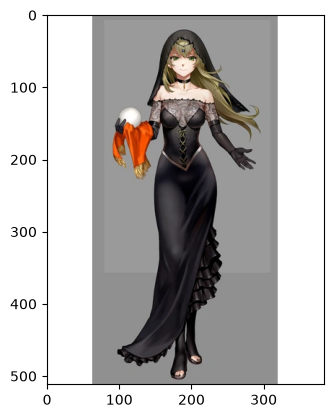

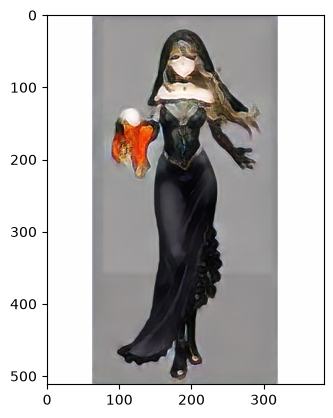

In [16]:
def tensor_neg1_1_to_display_image(x: torch.Tensor, channelFirst=True) -> torch.Tensor:
    """
    Convert a tensor image from [-1, 1] to display-ready [0, 1].

    Input:
        x shape: (3, H, W)

    Output:
        x_display shape: (H, W, 3), clipped to [0, 1]
    """
    x = x.detach().float().cpu()
    x = (x + 1.0) / 2.0
    x = x.clamp(0.0, 1.0)
    if channelFirst:
        x = x.permute(1, 2, 0)
    return x

dataset = ProcessedImageDataset(PROCESSED_ROOT)

vqgan_loader = DataLoader(
    dataset,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=cfg.num_workers,
    pin_memory=torch.cuda.is_available(),
    drop_last=True,
)

with torch.no_grad():
    original_0_1, x = next(iter(vqgan_loader))
    x = x.to(device, non_blocking=True)

    z_q, vq_loss, indices, z_e = autoencoder.encode(
        x,
        return_prequant=True,
    )
    x_hat = autoencoder.decode(z_q)

print("x:", x.shape)
print("z_e:", z_e.shape)
print("z_q:", z_q.shape)
print("indices:", indices.shape)
print("x_hat:", x_hat.shape)
print("vq_loss:", vq_loss.item())
print("codes used:", indices.unique().numel(), "/", cfg.n_embed)
plt.imshow(tensor_neg1_1_to_display_image(x[0].cpu()))
plt.show()
plt.imshow(tensor_neg1_1_to_display_image(x_hat[0].cpu()))

## Building The Latent Dataset

In [17]:
from pathlib import Path
import torch
from tqdm import tqdm

LATENT_DATASET_NAME = "LatentFantasy"
LATENT_OUTPUT_ROOT = Path("processedDatasets") / LATENT_DATASET_NAME
LATENT_OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

latent_source_dataset = ProcessedImageDataset(
    PROCESSED_ROOT,
    horizontal_flip_prob=0.0,
)

latent_loader = DataLoader(
    latent_source_dataset,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=torch.cuda.is_available(),
    drop_last=False,
)

autoencoder.eval()

saved_count = 0

if reconstruct_latent_dataset := True:
    
    with torch.no_grad():
        for batch_idx, batch in enumerate(tqdm(latent_loader, desc="Encoding latents")):
            original_0_1, x = batch
    
            # x is [-1, 1], shape (B, 3, 256, 192)
            x = x.to(device, non_blocking=True)
    
            # z is the continuous pre-quantization latent after tanh.
            # Shape: (B, 3, 64, 48)
            z_q, vq_loss, indices, z = autoencoder.encode(
                x,
                return_prequant=True,
            )
    
            z = z.detach().cpu().float()
    
            batch_size = z.shape[0]
    
            for i in range(batch_size):
                source_index = saved_count
                source_path = latent_source_dataset.image_paths[source_index]
    
                out_path = LATENT_OUTPUT_ROOT / f"{source_index:08d}.pth"
    
                torch.save(
                    {
                        "latent": z[i],
                        "source_path": str(source_path),
                        "source_index": source_index,
                        "latent_shape": tuple(z[i].shape),
                        "source_image_shape": (3, cfg.image_height, cfg.image_width),
                        "latent_type": "prequant_tanh",
                        "autoencoder_checkpoint": str(AUTOENCODER_CKPT_PATH),
                    },
                    out_path,
                )
    
                saved_count += 1
    
    print(f"Saved {saved_count} latent files to: {LATENT_OUTPUT_ROOT}")

Encoding latents: 100%|████████████████████████████████████████████████████████████| 1602/1602 [04:05<00:00,  6.52it/s]

Saved 12814 latent files to: processedDatasets/LatentFantasy


## EDM-Style Diffusion!! WAHOO!!!

In [18]:
parameters = {
    "sigma_min" : 0.002,
    "sigma_max" : 80,
    "sigma_data" : 0.5,
    "rho" : 7,
    "P_mean" : -1.2,
    "P_std" : 1.2,
    "N" : 128
}

## Data Sampling

I use the words image and latent interchangably since the diffusion process is fundementally the same. The only thing different is the shape of the underlying data you're trying to model.

Diffusion training works by repeatedly corrupting real images with noise and asking the model to undo that corruption.

Each training example consists of:

1. A clean image/latent $x$

2. A noisy image/latent, $x+ϵ$ where $ϵ\sim N(0,σ^2)$

3. A noise level $σ$


The model is trained across many noise levels so that it learns how images look at different amounts of corruption, from nearly clean to almost pure noise.

The noise level is sampled from a log-normal distribution so the model sees more intermediate noise levels where learning is most useful.

In [64]:
# THESE ARE UGLY BUT NECESSARY VARIABLES LEFT OVER FROM ME NOT BEING CAREFUL COPYING FROM A PREVIOUS TIME I WAS WORKING WITH EDM DIFFUSION ON IMAGE DATA DIRECTLY
# They were used for downsampling in that notebook since I couldn't do diffusion in high quality pixel space. However, since we're working in latent space in this project,
# these two values can be exactly the same as our actual latent data, so we're not doing any ugly downsampling of the data!

newHeight = 64
newWidth = 48
print(newHeight)
print(newWidth)

64
48


In [19]:
def sampleNoiseVector(sigma, height=64, width=48, channels=3):
    return np.random.normal(
        loc=0.0, 
        scale=sigma, 
        size=(height, width, channels)
    )
def sampleNoisedImage(latentPathList, P_mean = -1.2, P_std = 1.2, height=64, width = 48, device='cpu'):
    idx = random.randrange(0, len(latentPathList))
    filePath = latentPathList[idx]
    
    imageTensor = torch.load(filePath)['latent']
    imageTensor = einx.id("c h w -> h w c", imageTensor)
    logSigma = np.random.normal(loc=P_mean, scale=P_std)
    sigma = np.e ** logSigma
    noiseVec = torch.tensor(sampleNoiseVector(sigma, height=height, width=width))
    
    return imageTensor.to(device), (imageTensor + noiseVec).to(device), torch.tensor([sigma])

def sampleImageBatch(latentPathList, batch_size = 16, device='cpu', height=64, width = 48):
    trueImages = []
    noisedImages = []
    sigmaTensor = []
    classIndices = []
    for _ in range(batch_size):
        trueImage, noisedImage, sigma = sampleNoisedImage(latentPathList, height=height, width = width)
        trueImages.append(trueImage)
        noisedImages.append(noisedImage)
        sigmaTensor.append(sigma)
    return torch.stack(trueImages).float().to(device), torch.stack(noisedImages).float().to(device), torch.stack(sigmaTensor).float().to(device)


latentPathList = glob.glob(str(LATENT_OUTPUT_ROOT / "*"))
tmp = sampleNoisedImage(latentPathList, height=newHeight, width=newWidth, P_mean=-1.2)[1]
plt.imshow(tensor_neg1_1_to_display_image(tmp, channelFirst=False)) 

64
48


## Model Architecture

The model used here is a U-Net with attention modules, a common architecture for diffusion models.

A U-Net works well because it combines:

* Downsampling layers, which capture global structure.

* Upsampling layers, which reconstruct spatial detail.

* Skip connections, which preserve fine information across resolutions.

The model also receives the noise level as an input. This allows a single network to behave differently depending on how noisy the image is.

Generally speaking, early layers focus on texture and edges. Deeper layers learn object layout and shape. Attention layers help the model reason about long-range spatial relationships.

Modern diffusion models are largely improvements on this basic structure rather than entirely new architectures. However, you are free to experiment with any architecture, so long as the input size matches the output size matches the latent data size.


In [23]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class LearnedSigmaEmbedding(nn.Module):
    def __init__(self, emb_dim, hidden_dim=None):
        super().__init__()

        hidden_dim = hidden_dim or emb_dim

        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, emb_dim),
        )

    def forward(self, sigma):
        sigma = sigma.reshape(-1, 1).float()
        sigma = torch.log(sigma.clamp_min(1e-8))
        return self.net(sigma)


class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels, emb_dim):
        super().__init__()

        self.norm_in = nn.GroupNorm(32, in_channels)
        self.conv_in = nn.Conv2d(in_channels, out_channels, 3, padding=1)

        self.sigma_to_scale_shift = nn.Linear(emb_dim, out_channels * 2)

        self.norm_out = nn.GroupNorm(32, out_channels)
        self.conv_out = nn.Conv2d(out_channels, out_channels, 3, padding=1)

        self.skip = (
            nn.Identity()
            if in_channels == out_channels
            else nn.Conv2d(in_channels, out_channels, 1)
        )

        nn.init.zeros_(self.conv_out.weight)
        nn.init.zeros_(self.conv_out.bias)

    def forward(self, x, sigma_emb):
        h = self.conv_in(F.silu(self.norm_in(x)))

        scale, shift = self.sigma_to_scale_shift(F.silu(sigma_emb)).chunk(2, dim=1)

        h = self.norm_out(h)
        h = h * (1.0 + scale[:, :, None, None]) + shift[:, :, None, None]

        h = self.conv_out(F.silu(h))

        return self.skip(x) + h


class BottleneckAttention(nn.Module):
    def __init__(self, channels, heads=8):
        super().__init__()

        self.norm = nn.GroupNorm(32, channels)
        self.attention = nn.MultiheadAttention(
            embed_dim=channels,
            num_heads=heads,
            batch_first=True,
        )

    def forward(self, x):
        batch_size, channels, height, width = x.shape

        h = self.norm(x)
        h = h.flatten(2).transpose(1, 2)  # BCHW -> B, HW, C

        h, _ = self.attention(h, h, h, need_weights=False)

        h = h.transpose(1, 2).reshape(batch_size, channels, height, width)

        return x + h


class UNetDiffuser(nn.Module):
    """
    Input/output:
        batched:   (B, H, W, 3)
        unbatched: (H, W, 3)

    For our latent dataset:
        (B, 64, 48, 3)

    Spatial path:
        64x48 -> 32x24 -> 16x12 -> 8x6 -> 4x3 -> 8x6 -> 16x12 -> 32x24 -> 64x48
    """

    def __init__(self, base_channels=192, attention_heads=8):
        super().__init__()

        level_1_channels = base_channels          # 64 x 48
        level_2_channels = base_channels * 2      # 32 x 24
        level_3_channels = base_channels * 4      # 16 x 12
        level_4_channels = base_channels * 4      # 8 x 6
        bottleneck_channels = base_channels * 4   # 4 x 3

        sigma_emb_dim = bottleneck_channels

        self.sigma_embedding = LearnedSigmaEmbedding(
            emb_dim=sigma_emb_dim,
            hidden_dim=sigma_emb_dim * 4,
        )

        self.input_projection = nn.Conv2d(
            3,
            level_1_channels,
            kernel_size=3,
            padding=1,
        )

        # -------------------------
        # Encoder level 1: 64 x 48
        # -------------------------
        self.encoder_level_1_block_1 = ResBlock(
            level_1_channels,
            level_1_channels,
            sigma_emb_dim,
        )
        self.encoder_level_1_block_2 = ResBlock(
            level_1_channels,
            level_1_channels,
            sigma_emb_dim,
        )

        self.downsample_1_to_2 = nn.Conv2d(
            level_1_channels,
            level_2_channels,
            kernel_size=4,
            stride=2,
            padding=1,
        )

        # -------------------------
        # Encoder level 2: 32 x 24
        # -------------------------
        self.encoder_level_2_block_1 = ResBlock(
            level_2_channels,
            level_2_channels,
            sigma_emb_dim,
        )
        self.encoder_level_2_block_2 = ResBlock(
            level_2_channels,
            level_2_channels,
            sigma_emb_dim,
        )

        self.downsample_2_to_3 = nn.Conv2d(
            level_2_channels,
            level_3_channels,
            kernel_size=4,
            stride=2,
            padding=1,
        )

        # -------------------------
        # Encoder level 3: 16 x 12
        # -------------------------
        self.encoder_level_3_block_1 = ResBlock(
            level_3_channels,
            level_3_channels,
            sigma_emb_dim,
        )
        self.encoder_level_3_block_2 = ResBlock(
            level_3_channels,
            level_3_channels,
            sigma_emb_dim,
        )

        self.downsample_3_to_4 = nn.Conv2d(
            level_3_channels,
            level_4_channels,
            kernel_size=4,
            stride=2,
            padding=1,
        )

        # -------------------------
        # Encoder level 4: 8 x 6
        # -------------------------
        self.encoder_level_4_block_1 = ResBlock(
            level_4_channels,
            level_4_channels,
            sigma_emb_dim,
        )
        self.encoder_level_4_attention = BottleneckAttention(
            level_4_channels,
            heads=attention_heads,
        )
        self.encoder_level_4_block_2 = ResBlock(
            level_4_channels,
            level_4_channels,
            sigma_emb_dim,
        )

        self.downsample_4_to_bottleneck = nn.Conv2d(
            level_4_channels,
            bottleneck_channels,
            kernel_size=4,
            stride=2,
            padding=1,
        )

        # -------------------------
        # Bottleneck: 4 x 3
        # -------------------------
        self.bottleneck_block_1 = ResBlock(
            bottleneck_channels,
            bottleneck_channels,
            sigma_emb_dim,
        )
        self.bottleneck_attention_1 = BottleneckAttention(
            bottleneck_channels,
            heads=attention_heads,
        )
        self.bottleneck_block_2 = ResBlock(
            bottleneck_channels,
            bottleneck_channels,
            sigma_emb_dim,
        )
        self.bottleneck_attention_2 = BottleneckAttention(
            bottleneck_channels,
            heads=attention_heads,
        )
        self.bottleneck_block_3 = ResBlock(
            bottleneck_channels,
            bottleneck_channels,
            sigma_emb_dim,
        )

        # -------------------------
        # Decoder level 4: 4 x 3 -> 8 x 6
        # -------------------------
        self.upsample_bottleneck_to_4 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="nearest"),
            nn.Conv2d(
                bottleneck_channels,
                level_4_channels,
                kernel_size=3,
                padding=1,
            ),
        )

        self.decoder_level_4_merge_block = ResBlock(
            level_4_channels + level_4_channels,
            level_4_channels,
            sigma_emb_dim,
        )
        self.decoder_level_4_refine_block = ResBlock(
            level_4_channels,
            level_4_channels,
            sigma_emb_dim,
        )

        # -------------------------
        # Decoder level 3: 8 x 6 -> 16 x 12
        # -------------------------
        self.upsample_4_to_3 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="nearest"),
            nn.Conv2d(
                level_4_channels,
                level_3_channels,
                kernel_size=3,
                padding=1,
            ),
        )

        self.decoder_level_3_merge_block = ResBlock(
            level_3_channels + level_3_channels,
            level_3_channels,
            sigma_emb_dim,
        )
        self.decoder_level_3_refine_block = ResBlock(
            level_3_channels,
            level_3_channels,
            sigma_emb_dim,
        )

        # -------------------------
        # Decoder level 2: 16 x 12 -> 32 x 24
        # -------------------------
        self.upsample_3_to_2 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="nearest"),
            nn.Conv2d(
                level_3_channels,
                level_2_channels,
                kernel_size=3,
                padding=1,
            ),
        )

        self.decoder_level_2_merge_block = ResBlock(
            level_2_channels + level_2_channels,
            level_2_channels,
            sigma_emb_dim,
        )
        self.decoder_level_2_refine_block = ResBlock(
            level_2_channels,
            level_2_channels,
            sigma_emb_dim,
        )

        # -------------------------
        # Decoder level 1: 32 x 24 -> 64 x 48
        # -------------------------
        self.upsample_2_to_1 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="nearest"),
            nn.Conv2d(
                level_2_channels,
                level_1_channels,
                kernel_size=3,
                padding=1,
            ),
        )

        self.decoder_level_1_merge_block = ResBlock(
            level_1_channels + level_1_channels,
            level_1_channels,
            sigma_emb_dim,
        )
        self.decoder_level_1_refine_block = ResBlock(
            level_1_channels,
            level_1_channels,
            sigma_emb_dim,
        )

        self.output_norm = nn.GroupNorm(32, level_1_channels)
        self.output_projection = nn.Conv2d(
            level_1_channels,
            3,
            kernel_size=3,
            padding=1,
        )

        nn.init.zeros_(self.output_projection.weight)
        nn.init.zeros_(self.output_projection.bias)

    def forward(self, x, sigma):
        was_unbatched = False

        if x.ndim == 3:
            x = x.unsqueeze(0)
            was_unbatched = True

        if sigma.ndim == 0:
            sigma = sigma.unsqueeze(0)

        # BHWC -> BCHW
        x = x.permute(0, 3, 1, 2).contiguous()

        sigma_emb = self.sigma_embedding(sigma)

        # Encoder level 1: 64 x 48
        x = self.input_projection(x)

        x = self.encoder_level_1_block_1(x, sigma_emb)
        x = self.encoder_level_1_block_2(x, sigma_emb)
        skip_level_1 = x

        # Encoder level 2: 32 x 24
        x = self.downsample_1_to_2(x)

        x = self.encoder_level_2_block_1(x, sigma_emb)
        x = self.encoder_level_2_block_2(x, sigma_emb)
        skip_level_2 = x

        # Encoder level 3: 16 x 12
        x = self.downsample_2_to_3(x)

        x = self.encoder_level_3_block_1(x, sigma_emb)
        x = self.encoder_level_3_block_2(x, sigma_emb)
        skip_level_3 = x

        # Encoder level 4: 8 x 6
        x = self.downsample_3_to_4(x)

        x = self.encoder_level_4_block_1(x, sigma_emb)
        x = self.encoder_level_4_attention(x)
        x = self.encoder_level_4_block_2(x, sigma_emb)
        skip_level_4 = x

        # Bottleneck: 4 x 3
        x = self.downsample_4_to_bottleneck(x)

        x = self.bottleneck_block_1(x, sigma_emb)
        x = self.bottleneck_attention_1(x)
        x = self.bottleneck_block_2(x, sigma_emb)
        x = self.bottleneck_attention_2(x)
        x = self.bottleneck_block_3(x, sigma_emb)

        # Decoder level 4: 4 x 3 -> 8 x 6
        x = self.upsample_bottleneck_to_4(x)

        x = torch.cat([x, skip_level_4], dim=1)
        x = self.decoder_level_4_merge_block(x, sigma_emb)
        x = self.decoder_level_4_refine_block(x, sigma_emb)

        # Decoder level 3: 8 x 6 -> 16 x 12
        x = self.upsample_4_to_3(x)

        x = torch.cat([x, skip_level_3], dim=1)
        x = self.decoder_level_3_merge_block(x, sigma_emb)
        x = self.decoder_level_3_refine_block(x, sigma_emb)

        # Decoder level 2: 16 x 12 -> 32 x 24
        x = self.upsample_3_to_2(x)

        x = torch.cat([x, skip_level_2], dim=1)
        x = self.decoder_level_2_merge_block(x, sigma_emb)
        x = self.decoder_level_2_refine_block(x, sigma_emb)

        # Decoder level 1: 32 x 24 -> 64 x 48
        x = self.upsample_2_to_1(x)

        x = torch.cat([x, skip_level_1], dim=1)
        x = self.decoder_level_1_merge_block(x, sigma_emb)
        x = self.decoder_level_1_refine_block(x, sigma_emb)

        x = self.output_projection(F.silu(self.output_norm(x)))

        # BCHW -> BHWC
        x = x.permute(0, 2, 3, 1).contiguous()

        if was_unbatched:
            x = x.squeeze(0)

        return x

In [24]:
device_str = "cuda:0" if torch.cuda.is_available() else "cpu"

model = UNetDiffuser(
    base_channels=192,
    attention_heads=8,
).to(device_str)

num_params = sum(p.numel() for p in model.parameters())
print(f"params: {num_params:,} ({num_params / 1e6:.2f}M)")

trueImages, noisedImages, sigmaTensor = sampleImageBatch(
    latentPathList,
    batch_size=8,
    device=device_str,
    height=newHeight,
    width=newWidth,
)

with torch.no_grad():
    out = model(noisedImages, sigmaTensor)

print("input: ", noisedImages.shape)
print("output:", out.shape)

assert out.shape == noisedImages.shape

params: 209,848,131 (209.85M)
input:  torch.Size([8, 64, 48, 3])
output: torch.Size([8, 64, 48, 3])


## Loss Function & Preconditioning

See the EDM paper for a more thorough explanation on preconditioning. As far as I understand we hope to keep inputs and outputs of the model we intend to actually train relatively normalized to have nice mean and variance.

The import part is that in (almost) all frameworks, there exists a function, $D_\theta$, which is the function which we hope learns to predict the denoised image, $y$. That is to say, if $\theta$ is perfect then $D_\theta(y + n) = y$.

<br>

However, previous papers have found that it is easier to make a neural network predict the *noise* that you add rather than the *clear image* that you start with. That is to say, it is easier to train a neural network, $F_\theta(y+n)=n$. Then from that, *construct* $D_\theta(x) = x - F_\theta(x)$. *It's an exercise to you to do the 2 lines of algebra to justify that if you plug $y+n$ into this $D_\theta$, you still get $y$ as an output.*

<br>

This Nvidia paper takes that concept to an extreme and says, why don't we make the statistical properties of training $F_\theta$ *very* nice at the cost of having a significantly more algebraicly complicated formula:
\begin{gather*}
D_\theta(x;\sigma) = c_{skip}(\sigma)x + c_{out}(\sigma)F_\theta(c_{in}(\sigma)x ; c_{noise}(\sigma))
\end{gather*}
<br>

I have done the implementations below for you with the relevant functions basically just from their table, but I encourage you to look at the table in the paper to see how this differs from previous papers.

<br>


In any case, the most important thing to understand is that the role of $D_\theta$ with everything set up correctly is still the same, it is still a function which hopes to map $D_\theta(y+n ; \sigma) = y$. So if there's one thing you want to take away from this section / experiment with on your own, it's that if you ever want to see a denoised image from a noised image, it's not by calling the model you train directly. Your model is *not* being trained to do that in this notebook. See my function, `calcTrueDenoised` for the function you are looking for which *does* aim to output a "denoised" image.

In [25]:
def calcLambda(sigmaTensor, sigma_data=0.5):
    numerator = sigmaTensor ** 2 + sigma_data ** 2
    denom = (sigmaTensor * sigma_data) ** 2
    return numerator / denom

def calcSkipScaling(sigmaTensor, sigma_data = 0.5):
    numerator = sigma_data ** 2
    denom = sigmaTensor ** 2 + sigma_data ** 2
    return numerator / denom

def calcOutputScaling(sigmaTensor, sigma_data=0.5):
    numerator = sigmaTensor * sigma_data
    denom = (sigmaTensor ** 2 + sigma_data ** 2) ** 0.5
    return numerator / denom

def calcInputScaling(sigmaTensor, sigma_data = 0.5):
    numerator = 1
    denom = (sigmaTensor ** 2 + sigma_data ** 2) ** 0.5
    return numerator / denom

def calcNoiseCond(sigmaTensor):
    return 0.25 * torch.log(sigmaTensor)
print(sigmaTensor[:10])
calcInputScaling(sigmaTensor)[:10]

tensor([[1.3010],
        [0.3272],
        [0.4024],
        [1.1340],
        [5.8786],
        [0.0171],
        [0.3796],
        [0.4438]], device='cuda:0')


tensor([[0.7175],
        [1.6735],
        [1.5580],
        [0.8069],
        [0.1695],
        [1.9988],
        [1.5929],
        [1.4958]], device='cuda:0')

In [26]:
def calculateLoss(denoisingModel, trueImages, noisedImages, sigmaTensor):
    lamb = calcLambda(sigmaTensor, sigma_data = parameters['sigma_data'])
    c_skip = calcSkipScaling(sigmaTensor, sigma_data = parameters['sigma_data'])
    c_out = calcOutputScaling(sigmaTensor, sigma_data = parameters['sigma_data'])
    c_in = calcInputScaling(sigmaTensor, sigma_data = parameters['sigma_data'])
    c_noise = calcNoiseCond(sigmaTensor)
    
    # So that it can be broadcasted to be multiplied element wise against images in the batch
    c_in_expl = c_in.unsqueeze(-1).unsqueeze(-1)
    c_skip_expl = c_skip.unsqueeze(-1).unsqueeze(-1)
    c_out_expl = c_out.unsqueeze(-1).unsqueeze(-1)
    
    modelImageInput = c_in_expl * noisedImages
    modelOutput = denoisingModel(modelImageInput, c_noise)
    
    effectiveTrainingTarget = (1 / c_out_expl) * (trueImages - c_skip_expl * noisedImages)
    # These three lines if you follow the suggested expressions in the paper simplifies to
    # MSE(modelOutput, effectiveTrainingTarget) * some_constant_dependent_on_image_dimensions
    # Since lambda and c_out**2 are inverses, and the rest is a mean over the sum of your pixel errors
    # rather than the sum of your 
    interm = (modelOutput - effectiveTrainingTarget) ** 2
    normedDiff = torch.sum(einx.id("... h w c -> ... (h w c)", interm), dim=-1, keepdim=True)
    weightedLoss = lamb * (c_out ** 2) * normedDiff
    return torch.mean(weightedLoss)
model.to('cpu')
loss = calculateLoss(model, trueImages.to('cpu'), noisedImages.to('cpu'), sigmaTensor.to('cpu'))
print(loss)

tensor(8548.3633, grad_fn=<MeanBackward0>)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4423866..2.269904].


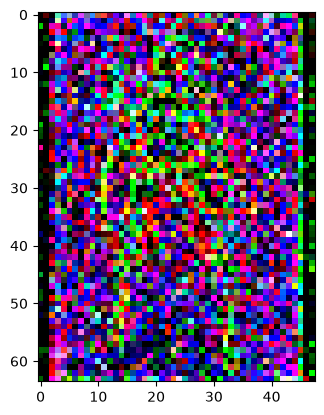

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.1229408..1.0436381].


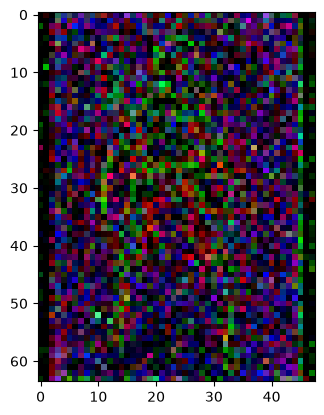

In [27]:
def calcTrueDenoised(denoisingModel, noisedImages, sigmaTensor):
    c_skip = calcSkipScaling(sigmaTensor, sigma_data = parameters['sigma_data'])
    c_out = calcOutputScaling(sigmaTensor, sigma_data = parameters['sigma_data'])
    c_in = calcInputScaling(sigmaTensor, sigma_data = parameters['sigma_data'])
    c_noise = calcNoiseCond(sigmaTensor)
    
    # So that it can be broadcasted to be multiplied element wise against images in the batch
    c_in_expl = c_in.unsqueeze(-1).unsqueeze(-1)
    c_skip_expl = c_skip.unsqueeze(-1).unsqueeze(-1)
    c_out_expl = c_out.unsqueeze(-1).unsqueeze(-1)

    return c_skip_expl * noisedImages + c_out_expl * denoisingModel(c_in_expl * noisedImages, c_noise)

def displayDenoisingProgress(model, noiseRange = (0.4, 0.6), device='cuda:0'):
    model.to(device)
    trueImages, noisedImages, sigmaTensor = sampleImageBatch(latentPathList, device=device, height=newHeight, width=newWidth, batch_size=64)
    for idx in range(sigmaTensor.shape[0]):
        if sigmaTensor[idx][0] > noiseRange[0] and sigmaTensor[idx][0] < noiseRange[1]:
            plt.imshow(noisedImages[idx].cpu().numpy())
            plt.show()
            with torch.no_grad():
                denoised = calcTrueDenoised(model, noisedImages[idx], sigmaTensor[idx])
            plt.imshow(denoised.cpu().numpy())
            plt.show()
            break
displayDenoisingProgress(model)

## Differential Equation Sampling

After training, image generation becomes a numerical simulation.

Starting from pure noise, we repeatedly:

1. Ask the model what the clean image should look like.

2. Move slightly in that direction.

3. Reduce the noise level.

This process can be interpreted as solving a differential equation that moves samples toward regions of high data probability.

We use Heun's method, a simple second-order solver, which improves stability and image quality compared to basic Euler updates.

In [21]:
def timeIndex(i, sigma_min, sigma_max, rho, N):
    sigmaDiff = sigma_min ** (1 / rho) - sigma_max ** (1 / rho)
    insideParenth = sigma_max ** (1 / rho) + (i / (N - 1)) * sigmaDiff
    return insideParenth ** rho 

def sigmaSchedule(t):
    return t

def computeTimeValues():
    timeIndices = []
    for idx in range(parameters["N"]):
        timeIndices.append(timeIndex(idx, parameters['sigma_min'], parameters['sigma_max'], parameters['rho'], parameters['N']))
    timeIndices.append(0)
    return timeIndices
timeValues = computeTimeValues()
print("t_0 through t_N")
print(f"{', '.join(str(x) for x in timeValues[:10])}...{', '.join(str(x) for x in timeValues[-10:])}")

t_0 through t_N
80.0, 76.62365808076356, 73.37019952280082, 70.23587449514882, 67.21702527325486, 64.3100845316542, 61.51157365787813, 58.818101087459674, 56.22636065990345, 53.73312999548703...0.008196339811421772, 0.006973725158819677, 0.005910883745528433, 0.004990022777169731, 0.004194971294060287, 0.0035110666704456605, 0.0029250465376888125, 0.0024249459985881193, 0.002000000000000003, 0


100%|████████████████████████████████████████████████████████████████████████████████| 128/128 [00:03<00:00, 40.17it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9314734..1.9563239].


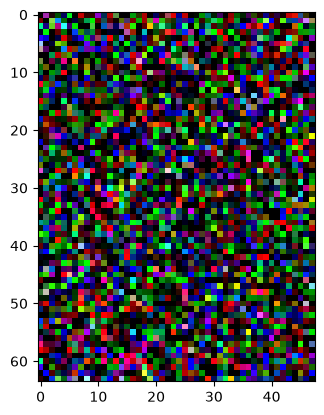

In [28]:
from tqdm import tqdm
timeValues = computeTimeValues()
def HeunSampleImage(denoisingModel, timeValues, device='cpu'):
    denoisingModel.to(device)
    generatedImages = []

    # Implicit assumption that sigma(t)=t and s(t) = 1 to make partial derivative calcs easy
    
    initImage = sampleNoiseVector(timeValues[0], height=newHeight, width=newWidth, channels=3)
    imgTensor = torch.tensor(initImage).float().to(device)
    generatedImages.append(imgTensor.detach().cpu().numpy())
    for i in tqdm(range(len(timeValues) - 1)):
        timeVal = timeValues[i]
        sigmaTensor = torch.tensor([timeVal]).float().to(device)
        denoisedPred = calcTrueDenoised(denoisingModel, imgTensor, sigmaTensor)
        dxdt = (imgTensor - denoisedPred) / timeVal
        imgTensorClone = imgTensor.clone()
        imgTensor = imgTensor + (timeValues[i + 1] - timeVal) * dxdt
        generatedImages.append(imgTensor.detach().cpu().numpy())

        if timeValues[i+1] != 0:
            sigmaTensor = torch.tensor([timeValues[i+1]]).float().to(device)
            dxdtprime = (imgTensor - calcTrueDenoised(denoisingModel, imgTensor, sigmaTensor)) / timeValues[i+1]
            imgTensor = imgTensorClone + (timeValues[i+1] - timeValues[i]) * (0.5 * dxdt + 0.5 * dxdtprime)

    return imgTensor, generatedImages
with torch.no_grad():
    aaa, generatedImages = HeunSampleImage(model, timeValues, 'cuda:0')
plt.imshow(aaa.cpu().numpy())

## Preparing For Model Training

Prepping an optimizer and an EMA object which we'll be actually using to denoise latents from at inference time.

In [32]:
for obj in dir():
    if isinstance(globals()[obj], torch.Tensor):
        del globals()[obj]
import gc
gc.collect()
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

import torch.optim as optim
model = UNetDiffuser(
    base_channels=192,
    attention_heads=8,
).to(device_str)


model.to('cuda:0')
optimizer = optim.AdamW(model.parameters(), lr = 1e-4)

In [34]:
total_params = sum(param.numel() for param in model.parameters())
print(total_params)

209848131


In [31]:
import copy
import torch
import matplotlib.pyplot as plt


ema_model = copy.deepcopy(model).eval()
for p in ema_model.parameters():
    p.requires_grad_(False)


@torch.no_grad()
def update_ema(ema_model, model, decay=0.999):
    for ema_p, p in zip(ema_model.parameters(), model.parameters()):
        ema_p.mul_(decay).add_(p, alpha=1.0 - decay)


@torch.no_grad()
def decode_hwc_latent(prequant_hwc, autoencoder):
    """
    prequant_hwc: (H, W, C)
    returns decoded image in [-1, 1], shape (1, 3, H*4, W*4)
    """
    z = prequant_hwc.permute(2, 0, 1).unsqueeze(0).contiguous()
    z = z.to(next(autoencoder.parameters()).device)

    z_q, _, indices = autoencoder.quantizer(z)
    x_hat = autoencoder.decode(z_q)

    return x_hat, z_q, indices


def show_hwc_latent(z, title=None):
    """
    z: (H, W, C), min-max scaled for display
    """
    z = z.detach().cpu().float()
    z = (z - z.min()) / (z.max() - z.min() + 1e-8)

    plt.imshow(z.numpy())
    if title:
        plt.title(title)
    plt.axis("off")
    plt.show()


def show_tensor_image(x, title=None):
    """
    x: (1, 3, H, W) or (3, H, W), in [-1, 1]
    """
    if x.ndim == 4:
        x = x[0]

    x = ((x.detach().cpu() + 1.0) / 2.0).clamp(0, 1)
    x = x.permute(1, 2, 0).numpy()

    plt.imshow(x)
    if title:
        plt.title(title)
    plt.axis("off")
    plt.show()

## Resuming Training

Set the walrus operator to True and specify the load path if you want to resume training from some saved weights. These weights are assumed to have been saved with the later defined Model/Optimizer Saving cell which defines the structure this is referencing.

In [33]:
from pathlib import Path
import torch

weights_dir = Path("weights")

main_path = weights_dir / "18HrsTraining_7-9-26_8HR.pth"
ema_path = weights_dir / "EMA_18HrsTraining_7-9-26_8HR.pth"

device_str = "cuda:0" if torch.cuda.is_available() else "cpu"

if load_from_weights := False:

    checkpoint = torch.load(main_path, map_location=device_str)

    model.load_state_dict(checkpoint["model_state_dict"])
    ema_model.load_state_dict(checkpoint["ema_model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    model.to(device_str)
    ema_model.to(device_str)

    model.train()
    ema_model.eval()

    for p in ema_model.parameters():
        p.requires_grad_(False)

    minLoss = checkpoint.get("minLoss", 1e1000)
    start_epoch = checkpoint.get("epoch", 0)

    print(f"Loaded full training checkpoint from: {main_path}")
    print(f"checkpoint epoch: {start_epoch}")
    print(f"checkpoint minLoss: {minLoss}")

Loaded full training checkpoint from: weights/14HrsTraining_7-9-26.pth
checkpoint epoch: 328062
checkpoint minLoss: 1219.6529541015625


## Model Training

alloc:5877MiB
reserved:7680MiB
max_alloc:6686MiB

epoch: 36000
loss: 1986.5575
min loss: 1359.6780
grad norm: 4486.9751
elapsed: 8300.969 secs


100%|████████████████████████████████████████████████████████████████████████████████| 128/128 [00:02<00:00, 50.70it/s]


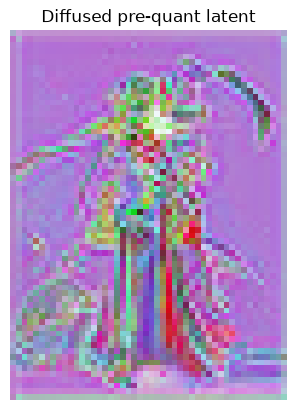

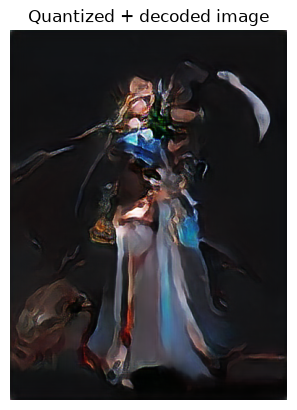

Delaying keyboard interrupt to save checkpoint


KeyboardInterrupt: 

In [35]:
import time

timeValues = computeTimeValues()
minLoss = 1e1000

device_str = "cuda:0"

model.to(device_str)
ema_model.to(device_str)
autoencoder.to(device_str)

model.train()
ema_model.eval()
autoencoder.eval()

for p in autoencoder.parameters():
    p.requires_grad_(False)

max_grad = 5000
minSaveInterval = 1000
epochsSinceLastSave = 0
saveIfLossBelow = 2000
batch_size = 8
printEvery = 250

imageGenProgress = []

run_name = f"train_{time.strftime('%Y%m%d_%H%M%S')}"
startTime = time.time()

for epoch in range(1000000):
    trueImages, noisedImages, sigmaTensor = sampleImageBatch(
        latentPathList,
        batch_size=batch_size,
        device=device_str,
        height=newHeight,
        width=newWidth,
    )

    optimizer.zero_grad(set_to_none=True)

    loss = calculateLoss(
        model,
        trueImages,
        noisedImages,
        sigmaTensor,
    )

    loss.backward()

    total_norm = torch.nn.utils.clip_grad_norm_(
        model.parameters(),
        max_grad,
    )

    optimizer.step()
    update_ema(ema_model, model, decay=0.999)

    epochsSinceLastSave += 1

    if loss.item() < minLoss:
        minLoss = loss.item()

    if loss.item() < saveIfLossBelow and epochsSinceLastSave > minSaveInterval:
        ckpt = {
            "model": model.state_dict(),
            "ema_model": ema_model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "epoch": epoch,
            "loss": float(loss.item()),
            "minLoss": float(minLoss),
            "run_name": run_name,
        }

        try:
            torch.save(ckpt, "ckpt-diffuser.pt")
        except KeyboardInterrupt:
            print("Delaying keyboard interrupt to save checkpoint")
            torch.save(ckpt, "ckpt-diffuser.pt")

        epochsSinceLastSave = 0

    if epoch % printEvery == 0:
        cuda_mem_str = (
            f"alloc:{torch.cuda.memory_allocated() // (1024**2)}MiB\n"
            f"reserved:{torch.cuda.memory_reserved() // (1024**2)}MiB\n"
            f"max_alloc:{torch.cuda.max_memory_allocated() // (1024**2)}MiB\n"
        )

        print(cuda_mem_str)
        print(
            f"""epoch: {epoch}
loss: {loss.item():.4f}
min loss: {minLoss:.4f}
grad norm: {float(total_norm):.4f}
elapsed: {time.time() - startTime:.3f} secs"""
        )

        with torch.no_grad():
            prequantizedDiffusedLatent, _ = HeunSampleImage(
                ema_model,
                timeValues,
                device_str,
            )

            decoded_image, z_q, indices = decode_hwc_latent(
                prequantizedDiffusedLatent,
                autoencoder,
            )

        show_hwc_latent(prequantizedDiffusedLatent, title="Diffused pre-quant latent")
        show_tensor_image(decoded_image, title="Quantized + decoded image")

        imageGenProgress.append(
            {
                "epoch": epoch,
                "latent": prequantizedDiffusedLatent.detach().cpu(),
                "decoded": decoded_image.detach().cpu(),
                "codes_used": indices.unique().numel(),
            }
        )

## Model/Optimizer Saving

Set the walrus operator to true and specify the save path to use in the diffusion notebook / resume training in this notebook.

In [36]:
from pathlib import Path
import torch
import time

weights_dir = Path("weights")
weights_dir.mkdir(parents=True, exist_ok=True)

main_path = weights_dir / "18HrsTraining_7-9-26_8HR.pth"
ema_path = weights_dir / "EMA_18HrsTraining_7-9-26_8HR.pth"

if saveWeights := False:
    # Full training checkpoint: raw model + optimizer + EMA.
    torch.save(
        ckpt := {
            "model_state_dict": model.state_dict(),
            "ema_model_state_dict": ema_model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "minLoss": float(minLoss) if "minLoss" in globals() else None,
            "epoch": epoch if "epoch" in globals() else None,
            "run_name": run_name if "run_name" in globals() else None,
            "saved_at": time.strftime("%Y-%m-%d %H:%M:%S"),
            "model_class": model.__class__.__name__,
        },
        main_path,
    )
    
    # EMA-only checkpoint for inference/sampling.
    torch.save(
        ema_ckpt := {
            "model_state_dict": ema_model.state_dict(),
            "minLoss": float(minLoss) if "minLoss" in globals() else None,
            "epoch": epoch if "epoch" in globals() else None,
            "run_name": run_name if "run_name" in globals() else None,
            "saved_at": time.strftime("%Y-%m-%d %H:%M:%S"),
            "model_class": ema_model.__class__.__name__,
        },
        ema_path,
    )
    
    print(f"Saved full checkpoint to: {main_path}")
    print(f"Saved EMA checkpoint to:  {ema_path}")
    print(f"Full checkpoint keys: {list(ckpt.keys())}")
    print(f"EMA checkpoint keys:  {list(ema_ckpt.keys())}")

Saved full checkpoint to: weights/14HrsTraining_7-9-26_8HR.pth
Saved EMA checkpoint to:  weights/EMA_14HrsTraining_7-9-26_8HR.pth
Full checkpoint keys: ['model_state_dict', 'ema_model_state_dict', 'optimizer_state_dict', 'minLoss', 'epoch', 'run_name', 'saved_at', 'model_class']
EMA checkpoint keys:  ['model_state_dict', 'minLoss', 'epoch', 'run_name', 'saved_at', 'model_class']


## Inference Visualizations

**Important!** By default, running this notebook top to bottom, this code cell will likely not run! That's because this requires some ema'd weights that you saved, probably in the previous cell if you set the walrus operator to True! If you didn't you would have to find some EMA model weights from somewhere. 

In [37]:
from pathlib import Path
import torch

weights_dir = Path("weights")

ema_path = weights_dir / "EMA_18HrsTraining_7-9-26_8HR.pth"

device_str = "cuda:0" if torch.cuda.is_available() else "cpu"

load_ema_only = True

if load_ema_only:
    checkpoint = torch.load(ema_path, map_location=device_str)

    ema_model.load_state_dict(checkpoint["model_state_dict"])
    ema_model.to(device_str)
    ema_model.eval()

    for p in ema_model.parameters():
        p.requires_grad_(False)

    print(f"Loaded EMA model from: {ema_path}")
    print(f"checkpoint epoch: {checkpoint.get('epoch')}")
    print(f"checkpoint minLoss: {checkpoint.get('minLoss')}")


Loaded EMA model from: weights/EMA_14HrsTraining_7-9-26_8HR.pth
checkpoint epoch: 36213
checkpoint minLoss: 1359.677978515625


In [40]:
import math
import torch
from tqdm import tqdm

def StochasticSampleImage(
    denoisingModel,
    timeValues,
    device='cpu',
    S_churn=40,
    S_tmin=0.05,
    S_tmax=50,
    S_noise=1.003,
):
    denoisingModel.to(device)
    denoisingModel.eval()

    generatedImages = []

    # Implicit assumption that sigma(t)=t and s(t)=1 to make partial derivative calcs easy.
    #
    # EDM stochastic sampling:
    #   gamma = min(S_churn / N, sqrt(2) - 1) if S_tmin <= t_i <= S_tmax else 0
    #   t_hat = t_i + gamma * t_i
    #   x_hat = x_i + sqrt(t_hat^2 - t_i^2) * S_noise * epsilon
    #
    # Then we take an Euler step from t_hat to t_{i+1}, followed by a Heun correction.

    initImage = sampleNoiseVector(timeValues[0], height=newHeight, width=newWidth, channels=3)
    imgTensor = torch.tensor(initImage).float().to(device)
    generatedImages.append(imgTensor.detach().cpu().numpy())

    numSteps = len(timeValues) - 1

    with torch.no_grad():
        for i in tqdm(range(numSteps)):
            timeVal = float(timeValues[i])
            nextTimeVal = float(timeValues[i + 1])

            # -------------------------
            # 1. Stochastic churn step
            # -------------------------
            if S_tmin <= timeVal <= S_tmax:
                gamma = min(S_churn / numSteps, math.sqrt(2) - 1)
            else:
                gamma = 0.0

            tHat = timeVal * (1 + gamma)

            if gamma > 0:
                noiseTensor = torch.randn_like(imgTensor) * S_noise
                noiseScale = math.sqrt(max(tHat ** 2 - timeVal ** 2, 0.0))
                imgTensor = imgTensor + noiseScale * noiseTensor

            # Save the pre-step tensor for the Heun correction.
            imgTensorClone = imgTensor.clone()

            # -------------------------
            # 2. Euler step
            # -------------------------
            sigmaTensor = torch.tensor([tHat]).float().to(device)
            denoisedPred = calcTrueDenoised(denoisingModel, imgTensor, sigmaTensor)

            dxdt = (imgTensor - denoisedPred) / tHat
            imgTensor = imgTensor + (nextTimeVal - tHat) * dxdt

            generatedImages.append(imgTensor.detach().cpu().numpy())

            # -------------------------
            # 3. Heun correction
            # -------------------------
            if nextTimeVal != 0:
                sigmaTensor = torch.tensor([nextTimeVal]).float().to(device)
                denoisedPredPrime = calcTrueDenoised(denoisingModel, imgTensor, sigmaTensor)

                dxdtprime = (imgTensor - denoisedPredPrime) / nextTimeVal

                imgTensor = imgTensorClone + (nextTimeVal - tHat) * (
                    0.5 * dxdt + 0.5 * dxdtprime
                )

    return imgTensor, generatedImages

## 5x5 Display grid of generated images.

In [66]:
from pathlib import Path
from io import BytesIO
import contextlib
import io
import shutil
import time

import torch
from PIL import Image
from IPython.display import display, HTML


SAVE_ROOT = Path("diffusionSavedImages") / "14Hrs_7-9-26_8HR"
CANDIDATE_ROOT = SAVE_ROOT / f"candidates_{time.strftime('%Y%m%d_%H%M%S')}"
CANDIDATE_ROOT.mkdir(parents=True, exist_ok=True)

GRID_ROWS = 5
GRID_COLS = 5
N_IMAGES = GRID_ROWS * GRID_COLS


def tensor_image_to_pil(x):
    if x.ndim == 4:
        x = x[0]

    x = ((x.detach().float().cpu() + 1.0) / 2.0).clamp(0, 1)
    x = x.permute(1, 2, 0).numpy()
    return Image.fromarray((x * 255).round().astype("uint8"))


def latent_hwc_to_pil(z, upscale=8):
    z = z.detach().float().cpu()
    z = ((z + 1.0) / 2.0).clamp(0, 1).numpy()

    img = Image.fromarray((z * 255).round().astype("uint8"))

    if upscale and upscale > 1:
        img = img.resize(
            (img.width * upscale, img.height * upscale),
            resample=Image.Resampling.NEAREST,
        )

    return img


candidate_dirs = []

print(f"Generating {N_IMAGES} candidates into:")
print(CANDIDATE_ROOT)

for i in range(N_IMAGES):
    out_dir = CANDIDATE_ROOT / f"candidate_{i:03d}"
    out_dir.mkdir(parents=True, exist_ok=False)

    with torch.no_grad():
        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            latent_hwc, _ = StochasticSampleImage(
                ema_model,
                timeValues,
                device_str,
                S_churn=40,
                S_tmin=0.05,
                S_tmax=50,
                S_noise=1.007
            )

        decoded_image, z_q, indices = decode_hwc_latent(
            latent_hwc,
            autoencoder,
        )

    latent_pil = latent_hwc_to_pil(latent_hwc, upscale=8)
    decoded_pil = tensor_image_to_pil(decoded_image)

    latent_pil.save(out_dir / "latent.png")
    decoded_pil.save(out_dir / "decoded.png")

    with open(out_dir / "meta.txt", "w") as f:
        f.write(f"candidate_index={i}\n")
        f.write(f"codes_used={int(indices.unique().numel())}\n")

    candidate_dirs.append(out_dir)
    print(f"saved candidate {i:03d} | codes used {int(indices.unique().numel())}")


html = """
<style>
.gallery {
    display: grid;
    grid-template-columns: repeat(5, 180px);
    gap: 16px;
    font-family: system-ui, -apple-system, BlinkMacSystemFont, sans-serif;
}
.card {
    border: 1px solid #ddd;
    border-radius: 10px;
    padding: 8px;
    background: #fafafa;
}
.card img {
    width: 100%;
    border-radius: 8px;
    display: block;
}
.label {
    margin-top: 6px;
    font-size: 13px;
    font-weight: 700;
    text-align: center;
}
.path {
    margin-top: 3px;
    font-size: 10px;
    color: #666;
    text-align: center;
    word-break: break-all;
}
</style>
<div class="gallery">
"""

for i, d in enumerate(candidate_dirs):
    decoded_path = d / "decoded.png"
    html += f"""
    <div class="card">
        <img src="{decoded_path.as_posix()}">
        <div class="label">candidate {i:03d}</div>
        <div class="path">{d.as_posix()}</div>
    </div>
    """

html += "</div>"

html_path = CANDIDATE_ROOT / "index.html"
html_path.write_text(html)

display(HTML(html))

print()
print("Wrote gallery HTML to:")
print(html_path)

Generating 25 candidates into:
diffusionSavedImages/14Hrs_7-9-26_8HR/candidates_20260709_221823
saved candidate 000 | codes used 868
saved candidate 001 | codes used 995
saved candidate 002 | codes used 1226
saved candidate 003 | codes used 1042
saved candidate 004 | codes used 1257
saved candidate 005 | codes used 1037
saved candidate 006 | codes used 759
saved candidate 007 | codes used 1230
saved candidate 008 | codes used 1166
saved candidate 009 | codes used 1080
saved candidate 010 | codes used 666
saved candidate 011 | codes used 982
saved candidate 012 | codes used 797
saved candidate 013 | codes used 819
saved candidate 014 | codes used 721
saved candidate 015 | codes used 844
saved candidate 016 | codes used 932
saved candidate 017 | codes used 990
saved candidate 018 | codes used 790
saved candidate 019 | codes used 963
saved candidate 020 | codes used 1185
saved candidate 021 | codes used 1424
saved candidate 022 | codes used 1049
saved candidate 023 | codes used 1116
saved


Wrote gallery HTML to:
diffusionSavedImages/14Hrs_7-9-26_8HR/candidates_20260709_221823/index.html


## Saving Display Grid Images

After running the cell above and making sure the folder paths line up as you want, specifying your favorite indices will save them. They're saved anyway these will just be saved in a more obvious spot.

In [63]:
from pathlib import Path
import shutil

SAVE_ROOT = Path("diffusionSavedImages") / "14Hrs_7-9-26_8HR"

# Fill this in after inspecting the gallery.
favorite_indices = [11, 12]  


def next_save_dir():
    existing = [
        int(p.name.replace("savedIm", ""))
        for p in SAVE_ROOT.glob("savedIm*")
        if p.is_dir() and p.name.replace("savedIm", "").isdigit()
    ]

    next_idx = 0 if len(existing) == 0 else max(existing) + 1
    out_dir = SAVE_ROOT / f"savedIm{next_idx:04d}"
    out_dir.mkdir(parents=True, exist_ok=False)
    return out_dir


for idx in favorite_indices:
    src_dir = CANDIDATE_ROOT / f"candidate_{idx:03d}"
    dst_dir = next_save_dir()

    shutil.copy2(src_dir / "latent.png", dst_dir / "latent.png")
    shutil.copy2(src_dir / "decoded.png", dst_dir / "decoded.png")

    if (src_dir / "meta.txt").exists():
        shutil.copy2(src_dir / "meta.txt", dst_dir / "meta.txt")

    print(f"saved candidate {idx:03d} -> {dst_dir}")

saved candidate 011 -> diffusionSavedImages/14Hrs_7-9-26_8HR/savedIm0009
saved candidate 012 -> diffusionSavedImages/14Hrs_7-9-26_8HR/savedIm0010
